In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option('display.max_columns', None)

In [97]:
import os

print(os.listdir('/content'))

['.config', 'drive', 'line_plot.png', 'histogram.png', 'bar_chart.png', 'scatter_plot.png', 'correlation_heatmap.png', '.ipynb_checkpoints', 'cleaned_data.csv', 'box_plot.png', 'WA_Fn-UseC_-Telco-Customer-Churn.zip', 'WA_Fn-UseC_-Telco-Customer-Churn.csv', 'sample_data']


In [98]:
import pandas as pd

df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [99]:
# Missing values count
missing_count = df.isnull().sum()

# Missing percentage
missing_percentage = (missing_count / len(df)) * 100

# Summary table
missing_df = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percentage
})

print(missing_df)

                  Missing Count  Missing Percentage
customerID                    0                 0.0
gender                        0                 0.0
SeniorCitizen                 0                 0.0
Partner                       0                 0.0
Dependents                    0                 0.0
tenure                        0                 0.0
PhoneService                  0                 0.0
MultipleLines                 0                 0.0
InternetService               0                 0.0
OnlineSecurity                0                 0.0
OnlineBackup                  0                 0.0
DeviceProtection              0                 0.0
TechSupport                   0                 0.0
StreamingTV                   0                 0.0
StreamingMovies               0                 0.0
Contract                      0                 0.0
PaperlessBilling              0                 0.0
PaymentMethod                 0                 0.0
MonthlyCharg

In [100]:
high_missing = missing_df[missing_df["Missing Percentage"] > 20]

print(high_missing)

Empty DataFrame
Columns: [Missing Count, Missing Percentage]
Index: []


In [101]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    missing_percent = (df[col].isnull().sum() / len(df)) * 100

    if 0 < missing_percent < 20:
        df[col] = df[col].fillna(df[col].median())

print("Numeric missing values filled successfully.")

Numeric missing values filled successfully.


In [102]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [103]:
# Task 3: Duplicate Detection and Removal

# Count duplicate rows
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

# Store shape before removing duplicates
rows_before = df.shape[0]

# Remove duplicates
df = df.drop_duplicates()

# Store shape after removing duplicates
rows_after = df.shape[0]

# Number of rows removed
rows_removed = rows_before - rows_after
print("Rows removed:", rows_removed)

# Check null percentage after removing duplicates
null_percentage_after = (df.isnull().sum() / len(df)) * 100

print("\nNull Percentage After Removing Duplicates:")
print(null_percentage_after)

Number of duplicate rows: 0
Rows removed: 0

Null Percentage After Removing Duplicates:
customerID          0.0
gender              0.0
SeniorCitizen       0.0
Partner             0.0
Dependents          0.0
tenure              0.0
PhoneService        0.0
MultipleLines       0.0
InternetService     0.0
OnlineSecurity      0.0
OnlineBackup        0.0
DeviceProtection    0.0
TechSupport         0.0
StreamingTV         0.0
StreamingMovies     0.0
Contract            0.0
PaperlessBilling    0.0
PaymentMethod       0.0
MonthlyCharges      0.0
TotalCharges        0.0
Churn               0.0
dtype: float64


In [104]:
# Task 4: Data Type Correction

# Check current data types
print("Data Types Before Conversion:\n")
print(df.dtypes)

# Memory usage before conversion
memory_before = df.memory_usage(deep=True).sum()
print("\nMemory Usage Before:", memory_before, "bytes")

# Convert TotalCharges from object to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Convert a repetitive string column to category
df['Contract'] = df['Contract'].astype('category')

# Check data types after conversion
print("\nData Types After Conversion:\n")
print(df.dtypes)

# Memory usage after conversion
memory_after = df.memory_usage(deep=True).sum()
print("\nMemory Usage After:", memory_after, "bytes")

print("\nMemory Saved:", memory_before - memory_after, "bytes")

Data Types Before Conversion:

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Memory Usage Before: 7152287 bytes

Data Types After Conversion:

customerID            object
gender                object
SeniorCitizen          int64
Partner               object
Dependents            object
tenure                 int64
PhoneService          object
MultipleLines         object
InternetService       object
OnlineSecurity        object
OnlineBack

In [105]:
# Task 5: Descriptive Statistics and Skewness

# Descriptive statistics
print("Descriptive Statistics:")
print(df.describe())

# Calculate skewness
print("\nSkewness of Numeric Columns:")

skewness = df.select_dtypes(include=['number']).skew()

print(skewness)

# Column with highest absolute skewness
highest_skew_col = skewness.abs().idxmax()

print("\nColumn with Highest Absolute Skewness:", highest_skew_col)
print("Skewness Value:", skewness[highest_skew_col])

Descriptive Statistics:
       SeniorCitizen       tenure  MonthlyCharges  TotalCharges
count    7043.000000  7043.000000     7043.000000   7032.000000
mean        0.162147    32.371149       64.761692   2283.300441
std         0.368612    24.559481       30.090047   2266.771362
min         0.000000     0.000000       18.250000     18.800000
25%         0.000000     9.000000       35.500000    401.450000
50%         0.000000    29.000000       70.350000   1397.475000
75%         0.000000    55.000000       89.850000   3794.737500
max         1.000000    72.000000      118.750000   8684.800000

Skewness of Numeric Columns:
SeniorCitizen     1.833633
tenure            0.239540
MonthlyCharges   -0.220524
TotalCharges      0.961642
dtype: float64

Column with Highest Absolute Skewness: SeniorCitizen
Skewness Value: 1.8336327440928564


In [106]:
# Task 6: Outlier Detection using IQR

numeric_cols = ['tenure', 'MonthlyCharges']

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"\nColumn: {col}")
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower Bound:", lower)
    print("Upper Bound:", upper)
    print("Number of Outliers:", len(outliers))


Column: tenure
Q1: 9.0
Q3: 55.0
IQR: 46.0
Lower Bound: -60.0
Upper Bound: 124.0
Number of Outliers: 0

Column: MonthlyCharges
Q1: 35.5
Q3: 89.85
IQR: 54.349999999999994
Lower Bound: -46.02499999999999
Upper Bound: 171.375
Number of Outliers: 0


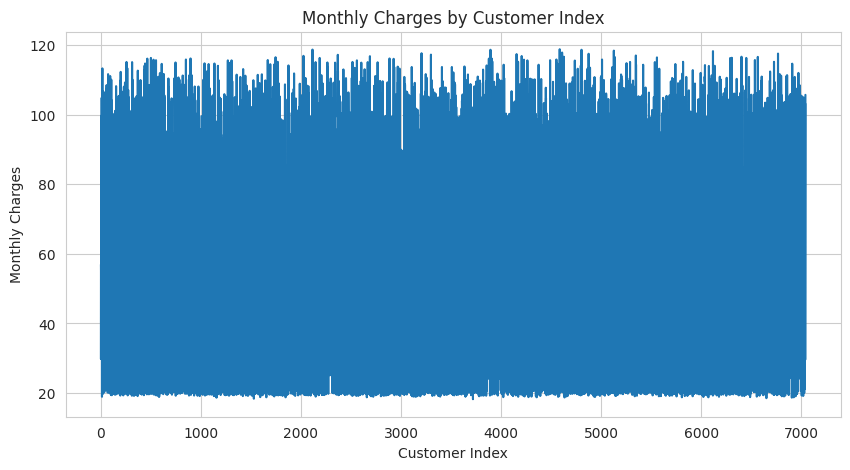

In [107]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df.index, df['MonthlyCharges'])
plt.title("Monthly Charges by Customer Index")
plt.xlabel("Customer Index")
plt.ylabel("Monthly Charges")
plt.grid(True)

plt.savefig("line_plot.png")
plt.show()

/tmp/ipykernel_1213/1858008410.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Contract')['MonthlyCharges'].mean().plot(kind='bar')


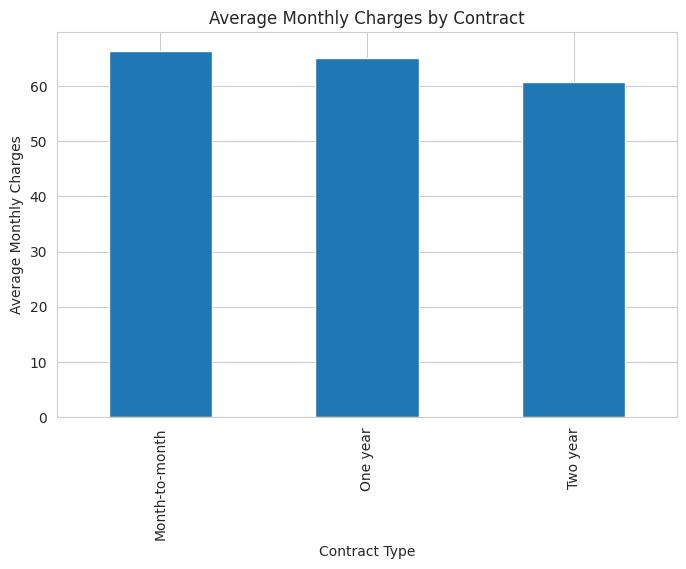

In [108]:
plt.figure(figsize=(8,5))

df.groupby('Contract')['MonthlyCharges'].mean().plot(kind='bar')

plt.title("Average Monthly Charges by Contract")
plt.xlabel("Contract Type")
plt.ylabel("Average Monthly Charges")

plt.savefig("bar_chart.png")
plt.show()

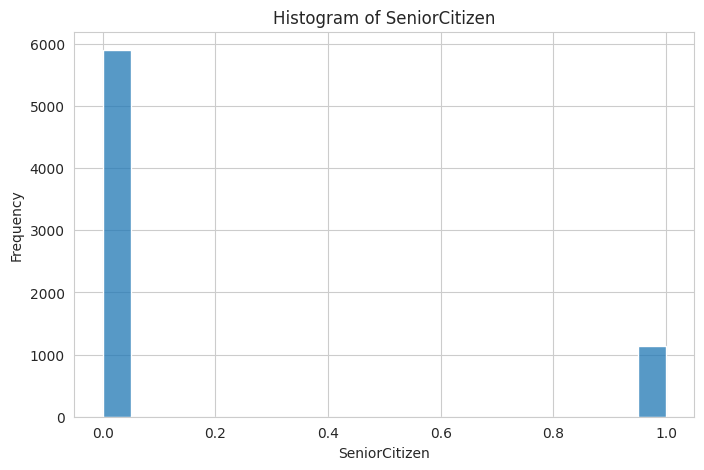

In [109]:
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(df['SeniorCitizen'], bins=20)

plt.title("Histogram of SeniorCitizen")
plt.xlabel("SeniorCitizen")
plt.ylabel("Frequency")

plt.savefig("histogram.png")
plt.show()

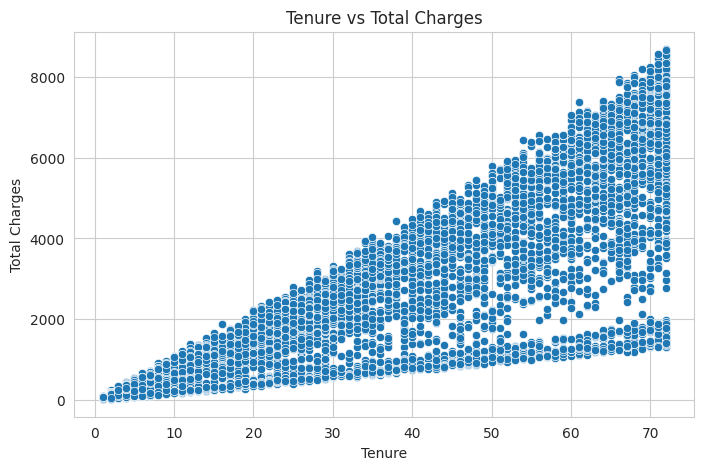

In [110]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=df, x='tenure', y='TotalCharges')

plt.title("Tenure vs Total Charges")
plt.xlabel("Tenure")
plt.ylabel("Total Charges")

plt.savefig("scatter_plot.png")
plt.show()

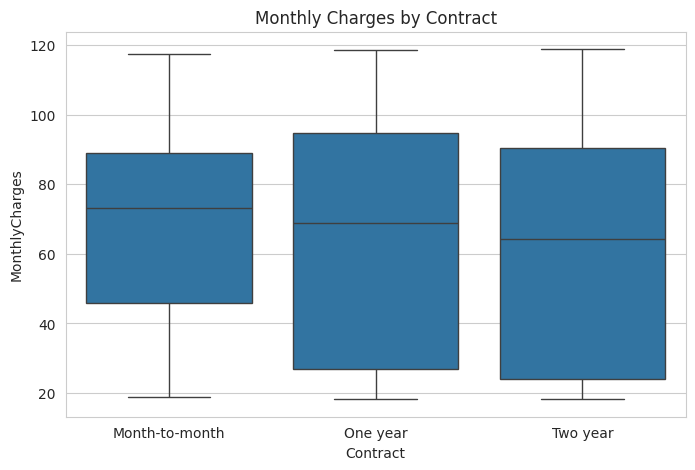

In [111]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x='Contract', y='MonthlyCharges')

plt.title("Monthly Charges by Contract")

plt.savefig("box_plot.png")
plt.show()

Correlation Matrix:
                SeniorCitizen    tenure  MonthlyCharges  TotalCharges
SeniorCitizen        1.000000  0.016567        0.220173      0.102411
tenure               0.016567  1.000000        0.247900      0.825880
MonthlyCharges       0.220173  0.247900        1.000000      0.651065
TotalCharges         0.102411  0.825880        0.651065      1.000000

Highest Correlation Pair: ('tenure', 'TotalCharges')
Correlation Value: 0.8258804609332019


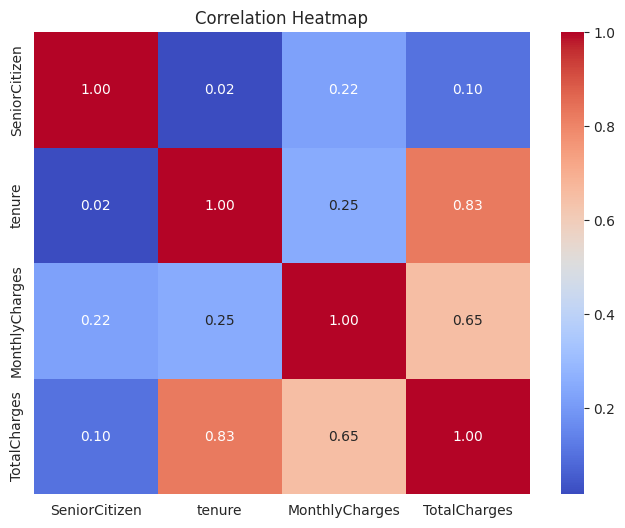

In [112]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns
numeric_df = df.select_dtypes(include=['number'])

# Pearson Correlation Matrix
correlation_matrix = numeric_df.corr()

print("Correlation Matrix:")
print(correlation_matrix)

# Find the highest absolute correlation (excluding self-correlation)
corr_copy = correlation_matrix.abs().copy()

# Remove diagonal values
import numpy as np
np.fill_diagonal(corr_copy.values, 0)

highest_pair = corr_copy.stack().idxmax()
highest_value = corr_copy.stack().max()

print("\nHighest Correlation Pair:", highest_pair)
print("Correlation Value:", highest_value)

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")
plt.savefig("correlation_heatmap.png")
plt.show()

In [113]:
# Task 9(a)

# Get the two most skewed numeric columns
skewness = df.select_dtypes(include='number').skew().abs()
top2_cols = skewness.sort_values(ascending=False).head(2).index

print("Top 2 Most Skewed Columns:", list(top2_cols))

for col in top2_cols:
    print(f"\nColumn: {col}")
    print("Mean :", df[col].mean())
    print("Median :", df[col].median())

    # Fill any remaining missing values using median
    df[col] = df[col].fillna(df[col].median())

print("\nRemaining Null Values:")
print(df[top2_cols].isnull().sum())

Top 2 Most Skewed Columns: ['SeniorCitizen', 'TotalCharges']

Column: SeniorCitizen
Mean : 0.1621468124378816
Median : 0.0

Column: TotalCharges
Mean : 2283.3004408418656
Median : 1397.475

Remaining Null Values:
SeniorCitizen    0
TotalCharges     0
dtype: int64


In [114]:
# Pearson Correlation
pearson = df.select_dtypes(include='number').corr()

# Spearman Correlation
spearman = df.select_dtypes(include='number').corr(method='spearman')

print("Pearson Correlation:")
print(pearson)

print("\nSpearman Correlation:")
print(spearman)

difference = (spearman - pearson).abs()

print("\nDifference Matrix:")
print(difference)

print("\nTop 3 Differences:")

top3 = (
    difference.where(~np.eye(difference.shape[0], dtype=bool))
    .stack()
    .sort_values(ascending=False)
    .drop_duplicates()
    .head(3)
)

print(top3)

Pearson Correlation:
                SeniorCitizen    tenure  MonthlyCharges  TotalCharges
SeniorCitizen        1.000000  0.016567        0.220173      0.102652
tenure               0.016567  1.000000        0.247900      0.825464
MonthlyCharges       0.220173  0.247900        1.000000      0.650864
TotalCharges         0.102652  0.825464        0.650864      1.000000

Spearman Correlation:
                SeniorCitizen    tenure  MonthlyCharges  TotalCharges
SeniorCitizen        1.000000  0.018556        0.221067      0.107256
tenure               0.018556  1.000000        0.276417      0.886998
MonthlyCharges       0.221067  0.276417        1.000000      0.637475
TotalCharges         0.107256  0.886998        0.637475      1.000000

Difference Matrix:
                SeniorCitizen    tenure  MonthlyCharges  TotalCharges
SeniorCitizen        0.000000  0.001989        0.000893      0.004604
tenure               0.001989  0.000000        0.028517      0.061534
MonthlyCharges       0.000

In [115]:
group = df.groupby("Contract")["MonthlyCharges"].agg(["mean", "std", "count"])

print(group)

highest_mean = group["mean"].idxmax()
highest_std = group["std"].idxmax()

print("\nHighest Mean Group:", highest_mean)
print("Highest Std Group:", highest_std)

ratio = group["mean"].max() / group["mean"].min()

print("Mean Ratio:", ratio)

                     mean        std  count
Contract                                   
Month-to-month  66.398490  26.926599   3875
One year        65.048608  31.840539   1473
Two year        60.770413  34.678865   1695

Highest Mean Group: Month-to-month
Highest Std Group: Two year
Mean Ratio: 1.0926121292797855


/tmp/ipykernel_1213/2834069958.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group = df.groupby("Contract")["MonthlyCharges"].agg(["mean", "std", "count"])


In [116]:
df.to_csv("cleaned_data.csv", index=False)

print("cleaned_data.csv has been saved successfully!")

cleaned_data.csv has been saved successfully!


In [117]:
# Part 2: Exploratory Data Analysis (EDA)

In [118]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

In [119]:
## 2.1 Churn Distribution

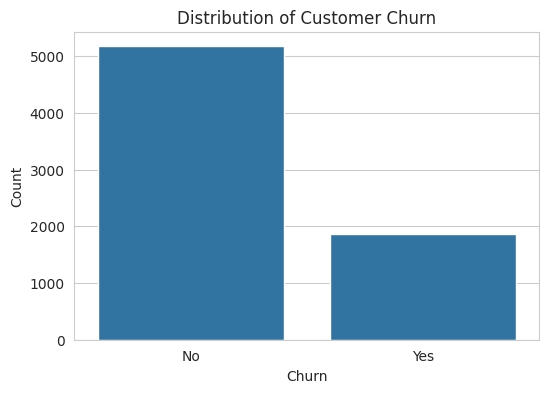

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Percentage:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [120]:
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df)

plt.title("Distribution of Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Count")

plt.show()

print(df['Churn'].value_counts())
print("\nPercentage:")
print(df['Churn'].value_counts(normalize=True)*100)

In [121]:
## 2.2 Gender vs Churn

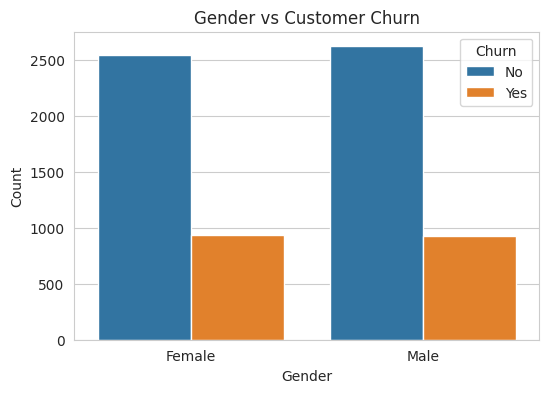

In [122]:
plt.figure(figsize=(6,4))
sns.countplot(x='gender', hue='Churn', data=df)

plt.title("Gender vs Customer Churn")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

In [123]:
## 2.3 Senior Citizen vs Churn

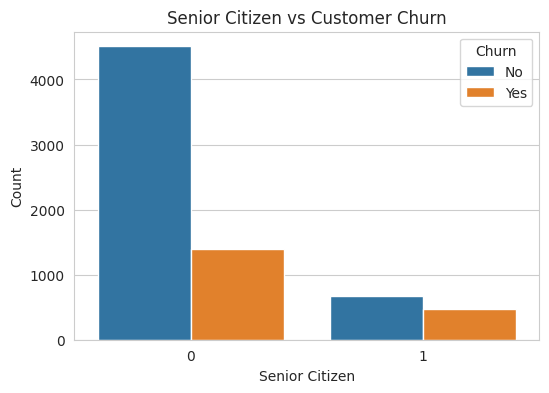

In [124]:
plt.figure(figsize=(6,4))
sns.countplot(x='SeniorCitizen', hue='Churn', data=df)

plt.title("Senior Citizen vs Customer Churn")
plt.xlabel("Senior Citizen")
plt.ylabel("Count")

plt.show()

In [125]:
## 2.4 Contract Type vs Churn

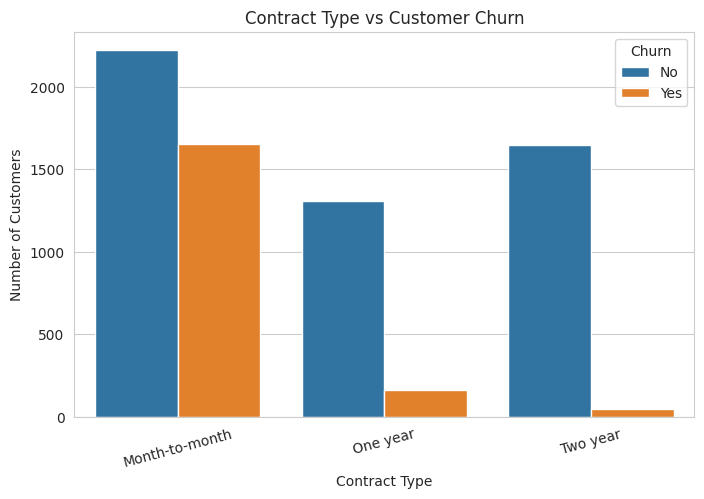

In [126]:
plt.figure(figsize=(8,5))
sns.countplot(x='Contract', hue='Churn', data=df)

plt.title("Contract Type vs Customer Churn")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=15)

plt.show()

In [127]:
## 2.5 Payment Method vs Churn

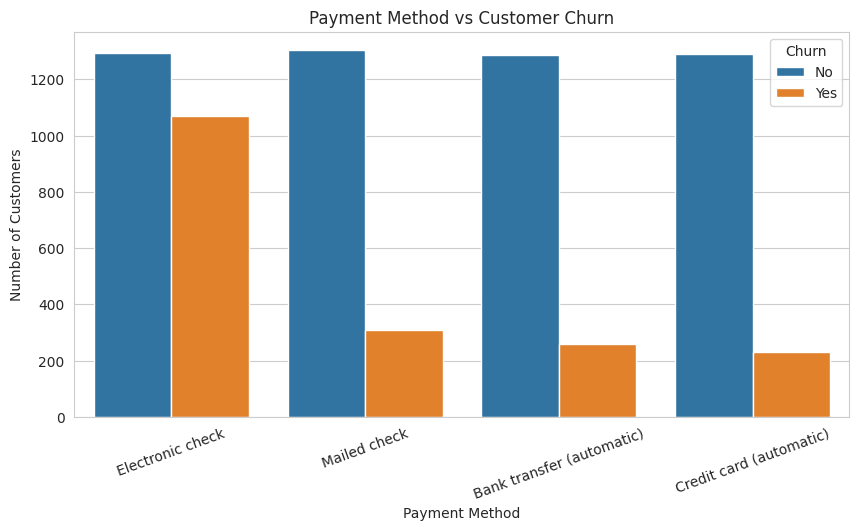

In [128]:
plt.figure(figsize=(10,5))
sns.countplot(x='PaymentMethod', hue='Churn', data=df)

plt.title("Payment Method vs Customer Churn")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)

plt.show()

In [129]:
## 2.6 Internet Service vs Churn

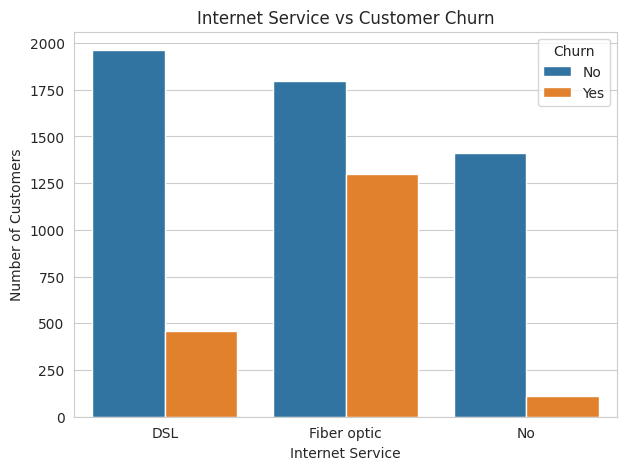

In [130]:
plt.figure(figsize=(7,5))
sns.countplot(x='InternetService', hue='Churn', data=df)

plt.title("Internet Service vs Customer Churn")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.show()

In [131]:
## 2.7 Distribution of Tenure

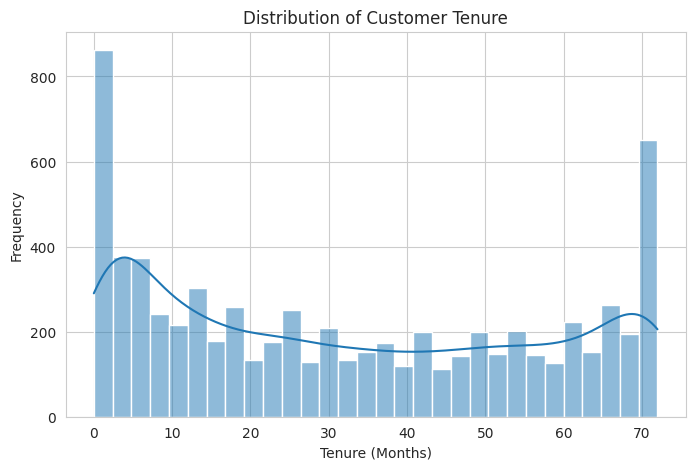

In [132]:
plt.figure(figsize=(8,5))
sns.histplot(df['tenure'], bins=30, kde=True)

plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Frequency")

plt.show()

In [133]:
## 2.8 Distribution of Monthly Charges

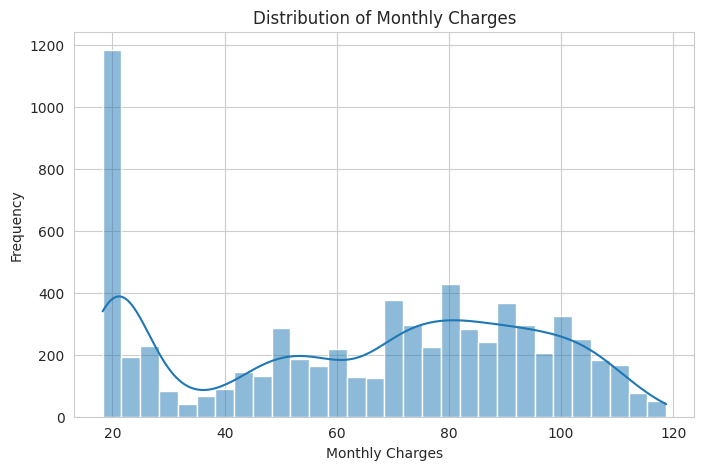

In [134]:
plt.figure(figsize=(8,5))
sns.histplot(df['MonthlyCharges'], bins=30, kde=True)

plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Frequency")

plt.show()

In [135]:
## 2.9 Distribution of Total Charges

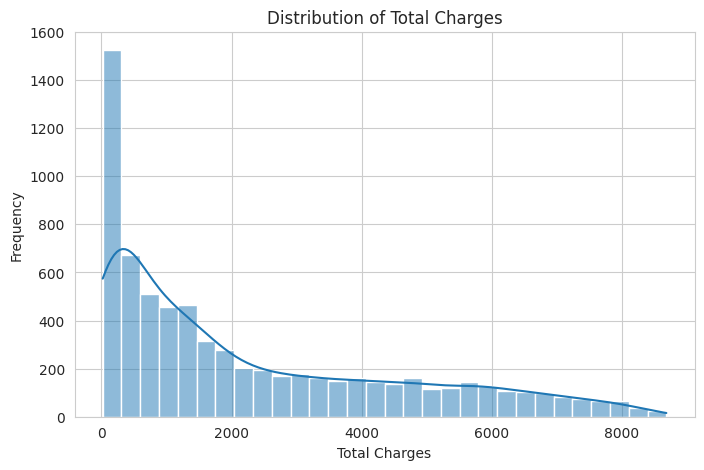

In [136]:
plt.figure(figsize=(8,5))
sns.histplot(df['TotalCharges'].dropna(), bins=30, kde=True)

plt.title("Distribution of Total Charges")
plt.xlabel("Total Charges")
plt.ylabel("Frequency")

plt.show()

In [137]:
## 2.10 Correlation Heatmap

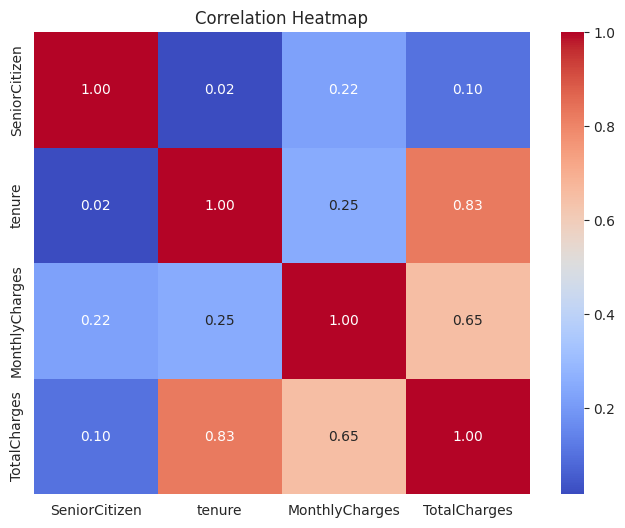

In [138]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

In [139]:
## 2.11 Monthly Charges by Churn

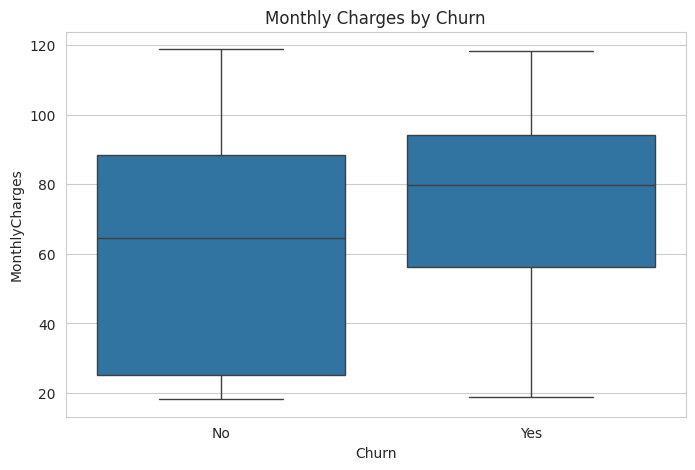

In [140]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Churn', y='MonthlyCharges', data=df)

plt.title("Monthly Charges by Churn")

plt.show()

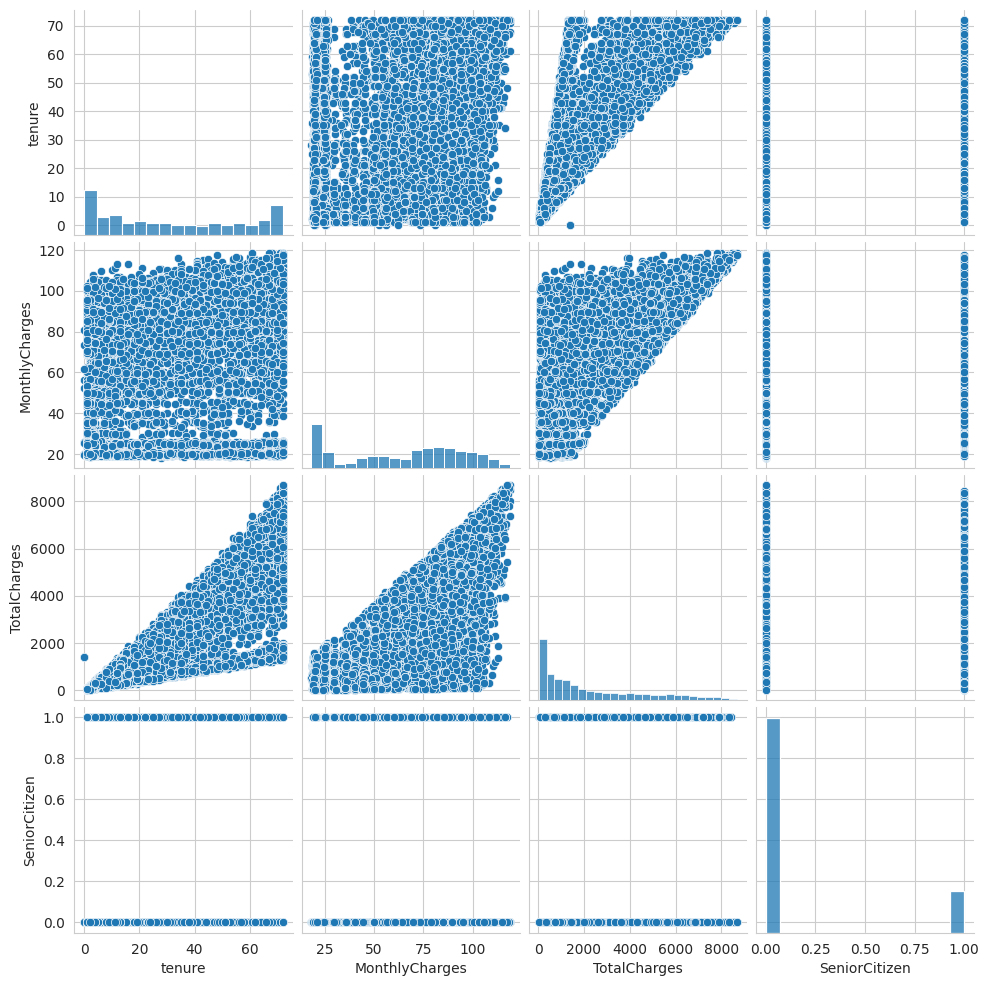

In [141]:
sns.pairplot(
    df[['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']],
    diag_kind='hist'
)
plt.show()

In [142]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import pandas as pd
import numpy as np

In [143]:
# Create a copy
ml_df = df.copy()

# Label Encode all object/category columns
le = LabelEncoder()

for col in ml_df.select_dtypes(include=['object', 'category']).columns:
    ml_df[col] = le.fit_transform(ml_df[col].astype(str))

ml_df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,5375,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,3962,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,2564,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,5535,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,6511,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


In [144]:
X = ml_df.drop("Churn", axis=1)
y = ml_df["Churn"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (7043, 20)
Target Shape: (7043,)


In [145]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])

Training Samples: 5634
Testing Samples: 1409


In [146]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [147]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.7963094393186657

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.64      0.55      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409



In [148]:
# Decision Tree
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.730305180979418

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.80      0.81      1035
           1       0.49      0.53      0.51       374

    accuracy                           0.73      1409
   macro avg       0.66      0.67      0.66      1409
weighted avg       0.74      0.73      0.73      1409



In [149]:
# Random Forest
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.7877927608232789

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.63      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409



In [150]:
# KNN
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_knn))

KNN Accuracy: 0.7544357700496807

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.84      0.83      1035
           1       0.54      0.52      0.53       374

    accuracy                           0.75      1409
   macro avg       0.68      0.68      0.68      1409
weighted avg       0.75      0.75      0.75      1409



In [151]:
# SVM
svm = SVC()

svm.fit(X_train_scaled, y_train)

y_pred_svm = svm.predict(X_test_scaled)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.794180269694819

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1035
           1       0.65      0.49      0.56       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



In [152]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "KNN",
        "SVM"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_svm)
    ]
})

results = results.sort_values(by="Accuracy", ascending=False)

results

,Model,Accuracy
0,Logistic Regression,0.796309
4,SVM,0.794180
2,Random Forest,0.787793
3,KNN,0.754436
1,Decision Tree,0.730305


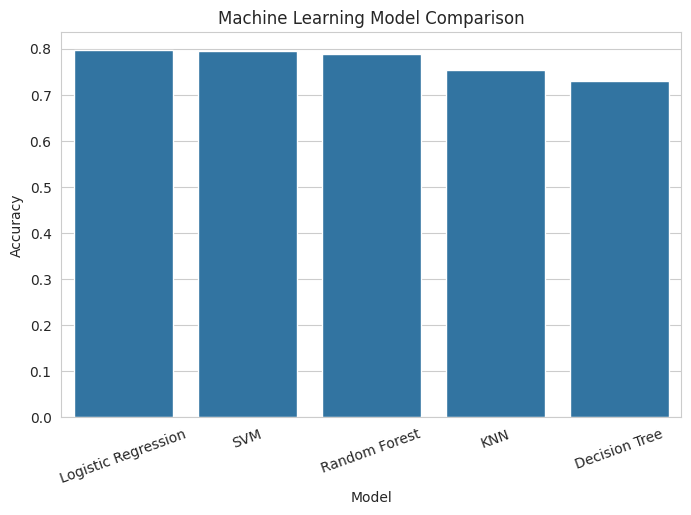

In [153]:
plt.figure(figsize=(8,5))

sns.barplot(data=results, x="Model", y="Accuracy")

plt.title("Machine Learning Model Comparison")
plt.xticks(rotation=20)

plt.show()

In [154]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(10))

            Feature  Importance
19     TotalCharges    0.154801
18   MonthlyCharges    0.146027
5            tenure    0.139221
0        customerID    0.130045
15         Contract    0.078078
9    OnlineSecurity    0.045168
17    PaymentMethod    0.042203
12      TechSupport    0.037041
8   InternetService    0.027018
10     OnlineBackup    0.024804
